# Question 9

## Theory

Gradient Decent is a technique to reach the global mininum of a functin by adjust weigts based on a partial derivative of error functions. It is more so based on finding such an error via subtracting a desiered output from a predicted output. This can be stated specifically as:

$e(w) = d(x)-o(x) = d - \sum_{j=0}^m x_j w_j$

- d: the desiered output
- o: the predicted output
- x: the input values of the instance
- w: the weight associated with each instance. 

The gradient descent rule operates primarily via a quadratic of the error squared i.e., the root mean error squared, expressed as $E(w)$, where 

$E(w) = \frac{1}{2} e^2$

As the function is quadratic, it reaches a lowest point known as the global mininum, which gives the best line of fit/hyperbolic plane for proper class seperation.

Without getting into too much detail the weights of a function are adjusted based on partial derivatives relative to each individual weight. 

$w (k+1) = w(k) - \eta \frac{\partial E(W)}{\partial w}$

The partial derivative, due to the predicted output subtracted from the desiered output, cancles out the subtracted, resulted in the initial weight being added to the error calculated weight.

This all evaluates as the initial weight gradient added to the new weight gradient multiplied by a learning coefficient $\eta$ and the error of desiered subracted from predicted outputs multipled by the values of each instances. There are two Gradient descent learning rules that can be applied, the general Gradient Descent Learning Rule:

$w_i (k+1) = w_i (k) + \Delta w(i)$
$w_i (k+1) = w_i (k) + \eta \sum_{n}(d(n)-o(n)x_i (n))$

Which utilizes a batch sum of instances, or Gradient Descent that uses the Delta Rule, i.e., AdaLine: Adaptive Linear Elements, to update the weights via one randomly selected instance

$w (k+1) = w(k) + \eta (d(n)-o(n))x(n)$



## Implimentation of theory


For this question, two functions of two dimensions are given

$f_1 (x,y) = (x-2)^2 + (y-3)^2$

$f_2 (x,y) = (1- (y-3))^2 + 20((x+3) - (y-3)^2)^2$

To evaluate gradient descent with repsect to $f_1 (x,y)$ and $f_2 (x,y)$, their partial derivatives with respect to x and y can be evaluated.

For $f_1 (x,y)$:

partial derivative with respect to x: 
$2(x-2)$

partial derivative with respect to y: 
$2(y-3)$

Ergo, the global mininum for $f_1 (x,y)$ is $f_1 (2,3)$

For $f_2 (x,y)$

partial derivative with respect to x: 
$40((x+3)-(y-3)^2)$

partial derivative with respect to y:
$-2(1-(y-3))-80((x+3)-(y-3)^2)(y-3)$

Ergo,the global mininum for $f_2 (x,y) is $f_2 (x,y)$ is $f_2 (-2,4)$


Follwing the weight updating rule $w_i (k+1) = w_i (k) - \eta \Delta w_i$

The functions for updating x and y values corresponding to a global minimum for the gradients can follow this form:

$x_(k+1) = x(k) - \eta * \frac{\partial f}{\partial x}$

$y(k+1) = y(k) - \eta * \frac{\partial f}{\partial y}$ 

In [57]:
# imports 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Union


## Q9.1

Plotting $f_1 (x,y)$ and $f_2 (x,y)$

In [4]:
# Define functions f_1(x,y) and f_2(x,y) 
# 
# f_1(x,y) and f_2(x,y) are two dimensional. As such, plottin them invovles a 
# third dimension, as opposed to an f(x) function. One method to do this is via a meshgrid
# As such, the functions are plooted on the Z-axis relative to x and y
# for f_1(x,y) and f_2(x,y)= where Z = f(x,y)

# Initialize mesgrid for plotting and setting x and y values:

x_val = np.linspace(-15, 15, 100)
y_val = np.linspace(-15, 15, 100)
x, y = np.meshgrid(x_val, y_val)

# Set the original functions f_1(x,y) and f_2(x,y) as z_1 and z_2
z_1 = ((x-2)**2)  + ((y-3)**2)
z_2 = (1-(y-3))**2 + 20*((x+3)-(y-3)**2)**2


Plotting can be done in either of two ways, as a 2D contour map or a 3D surface.

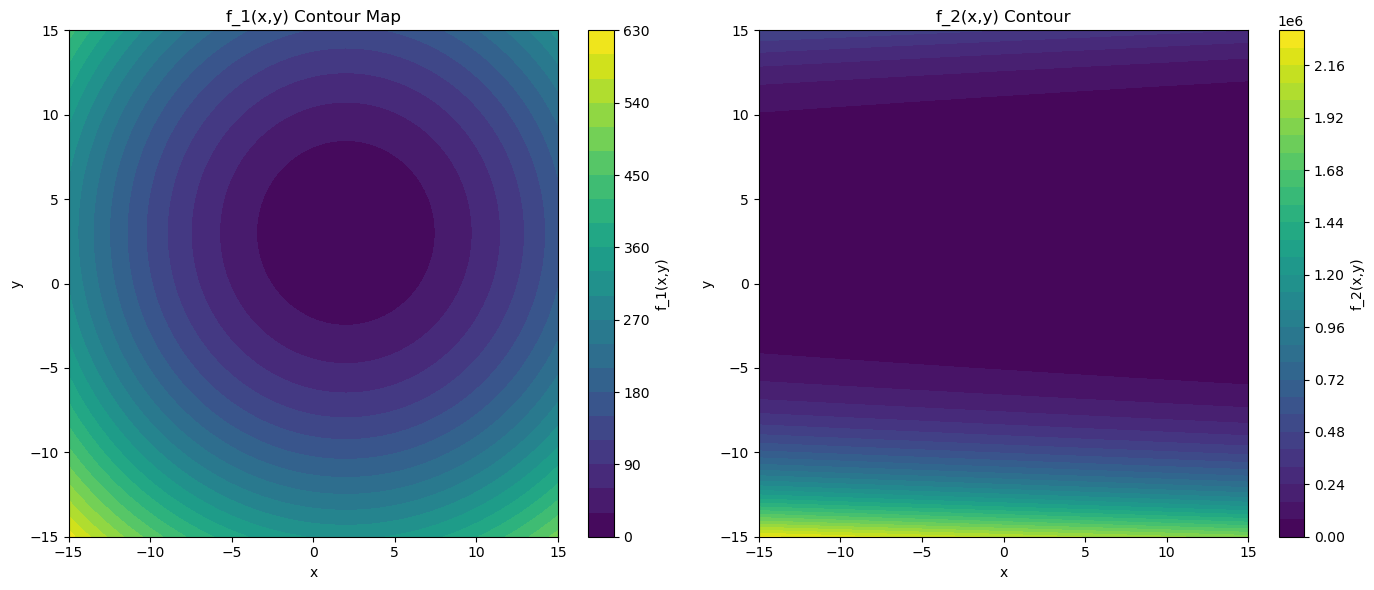

In [5]:
# Plotting as a 2D-contour map

# Set up 2D plot 
fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for f_1
cp1 = ax_1.contourf(x_val, y_val, z_1, levels=20, cmap="viridis")
fig.colorbar(cp1, ax=ax_1, label="f_1(x,y)")
ax_1.set_title("f_1(x,y) Contour Map")
ax_1.set_xlabel("x")
ax_1.set_ylabel("y")

# Plot f_2 
cp2 = ax_2.contourf(x_val, y_val, z_2, levels=30, cmap="viridis")
fig.colorbar(cp2, ax=ax_2, label="f_2(x,y)")
ax_2.set_title("f_2(x,y) Contour")
ax_2.set_xlabel("x")
ax_2.set_ylabel("y")

plt.tight_layout()
plt.show()

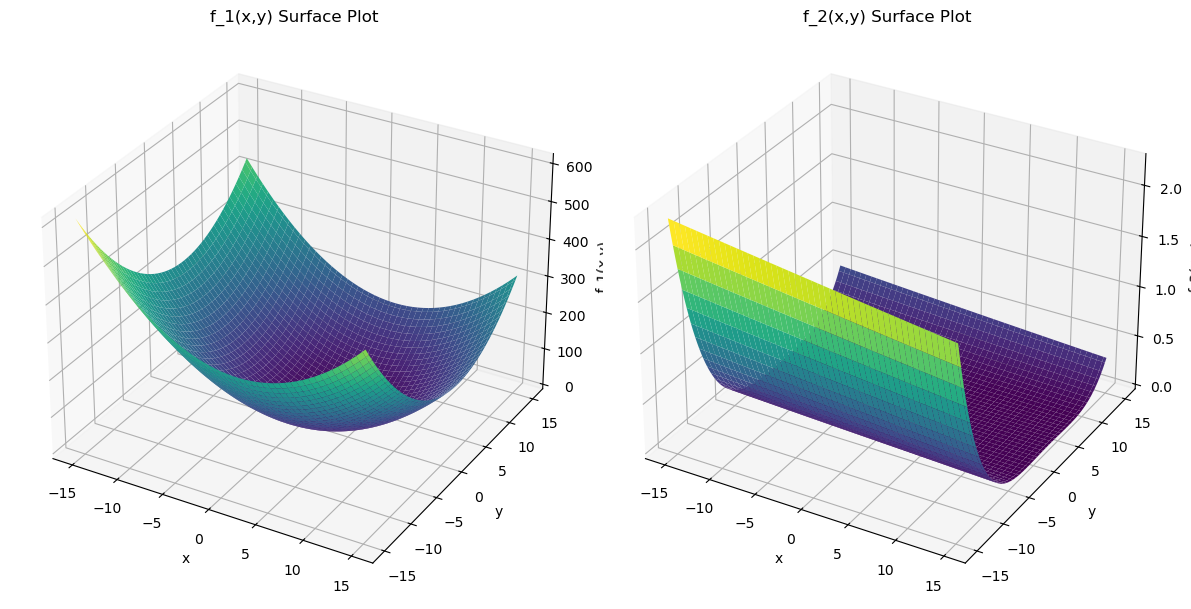

In [6]:
# Plotting as 3d surfaces

# 3d plots
fig = plt.figure(figsize=(12,6))

#f_1 plot
ax_1 = fig.add_subplot(121, projection = '3d')
ax_1.plot_surface(x, y, z_1, cmap = 'viridis')
ax_1.set_title('f_1(x,y) Surface Plot')
ax_1.set_xlabel('x')
ax_1.set_ylabel('y')
ax_1.set_zlabel('f_1(x,y)')

#f_2 plot
ax_2 = fig.add_subplot(122, projection='3d')
ax_2.plot_surface(x, y, z_2, cmap='viridis')
ax_2.set_title('f_2(x,y) Surface Plot')
ax_2.set_xlabel('x')
ax_2.set_ylabel('y')
ax_2.set_zlabel('f_2(x,y)')

plt.tight_layout()
plt.show()

## Q9.2 

Applying gradient descent to $f_1 (x,y)$ and $f_2 (x,y)$

Like gradient descent for weight updates within a dataset, x inputs are updated with values that lead to the global mininum of the functions.

Gradient Descent updating can be defined as functions $f_1 (x,y)$ and $f_2 (x,y)$

In [71]:
def f_1_GD(x1=0, y1=0, eta=0.5, T=100 ):

    """A definition for conducting gradient descent for f_1 (x,y) function  to find 
    a global mininum for x and y values for the funciton. Arguments include learning rule eta; 
    ;iteration T. x1 and y1 are initialized to 0 values for the x and y variables

    """

    # applying gradient descent to find global mininum for x and y values for f_1(x,y)

    # helper function: compute f_1 value
    def compute_f1(x,y): 
        val = (x - 2) ** 2 + (y - 3) ** 2
        return val

    # initialize arrays
    f_1_x_update = [x1];
    f_1_y_update = [y1];

    # initialize update function f_1(x,y) array to plot global minimum
    f_1_val_update = [compute_f1(x1,y1)];

    for i in range(T):

        # Graidents for partial derivatves:

        # partial deriviate of f_1 with respect to x
        grad_x = 2*(x1-2)
    
        # partial derivative of f_1 with respect to y
        grad_y = 2*(y1-3)

        # updating x and y:
        x1 = x1 - eta*grad_x
        y1 = y1 - eta*grad_y

        # compute a new value for the function
        f_val = compute_f1(x1,y1)

        # record x and y as arrays
        f_1_x_update.append(x1)
        f_1_y_update.append(y1)
        f_1_val_update.append(f_val)

    # display updated x and y values as a table
    xy_update_f_1 = pd.DataFrame({
        'Iteration - T': range(0, len(f_1_x_update)),
        'x': f_1_x_update,
        'y': f_1_y_update,
        'f1_value': f_1_val_update
    })

    print("Gradient Descent for f1(x,y) with eta = 0.5")
    print(xy_update_f_1)
    return f_1_val_update, f_1_x_update, f_1_y_update


In [68]:
def f_2_GD(x2=0, y2=0, eta2=0.5, T2=100, max_grad=100.0):

    """A definition for conducting gradient descent for f_2 (x,y) function  to find 
        a global mininum for x and y values for the funciton. Arguments include learning rule eta2; 
        ; iteration T2. x2 and y2 are initialized to 0 values for the x and y variables
    
    """

       # applying gradient descent to find global mininum for x and y values for f_2(x,y)
    
    # helper function: compute f_2 value
    def compute_f2(x,y): 
        val = (1-(y-3))**2 + 20*((x+3)-(y-3)**2)**2
        return val
    
    # initiazlie arrays to store values for x, y, and function value
    f_2_x_update = [x2]
    f_2_y_update = [y2]
    f_2_val_update = [compute_f2(x2,y2)]

    for i in range(T2):
        # Gradients for partial derivatives of f_2:
        grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
        grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)

        ##### Error handling 1 #####
        # Large eta values can result in 'overflow' errors due to gradient descent essentiall
        # going towards infinity. As such, for large eta values, the gradient can be clipped
        grad_x2 = np.clip(grad_x2, -max_grad, max_grad)
        grad_y2 = np.clip(grad_y2, -max_grad, max_grad)
        
        # updating x and y
        x2 = x2 - eta2 * grad_x2
        y2 = y2 - eta2 * grad_y2

        # compute a new value for the function
        f_val = compute_f2(x2,y2)

        ##### Error handling 2 #####
        # An extra precaution in case eta is too large - account for overflow error
        if np.isnan(f_val) or np.isinf(f_val):
            print(f"0verflow/Divergence detected in iteration {i+1}. Stopping")
            break
        
        # record the updated x and y
        f_2_x_update.append(x2)
        f_2_y_update.append(y2)
        f_2_val_update.append(f_val)

    print("Gradient Descent for f2(x,y) with eta = 0.001")
    print(pd.DataFrame({
        'Iteration - T': range(0, len(f_2_x_update)), 
        'x': f_2_x_update, 
        'y': f_2_y_update, 
        'f2_value': f_2_val_update
        }))
    return f_2_val_update, f_2_x_update, f_2_y_update

In [81]:
#Appliying f_1 function
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.5)


Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T    x    y  f1_value
0                0  0.0  0.0      13.0
1                1  2.0  3.0       0.0
2                2  2.0  3.0       0.0
3                3  2.0  3.0       0.0
4                4  2.0  3.0       0.0
..             ...  ...  ...       ...
96              96  2.0  3.0       0.0
97              97  2.0  3.0       0.0
98              98  2.0  3.0       0.0
99              99  2.0  3.0       0.0
100            100  2.0  3.0       0.0

[101 rows x 4 columns]


In [82]:
#Applying f_2 function
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.5)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T      x     y     f2_value
0                0    0.0   0.0        736.0
1                1   50.0  50.0   92968836.0
2                2  100.0   0.0     176736.0
3                3   50.0 -50.0  151913636.0
4                4  100.0   0.0     176736.0
..             ...    ...   ...          ...
96              96  100.0   0.0     176736.0
97              97   50.0 -50.0  151913636.0
98              98  100.0   0.0     176736.0
99              99   50.0 -50.0  151913636.0
100            100  100.0   0.0     176736.0

[101 rows x 4 columns]


Vizualising graident descent: The gradient descent can be easier visaulized by plotting the values of f_1(x,y) as x and y are going towards a global mininum. Countour plots can again be used to plot the descent path of (x,y) as they go toward a global mininum.

This can be done via making a plotting function

In [79]:
def plt_GD(f_val_update, f_x_update, f_y_update, title: str, f: Union[int, str] = 1, margin=2.0, grid_min=-5, grid_max=5, lin_val=200, eta: Union[float, str] = 0.5):

    """A function for plotting and vizualising gradient descent via a line chart and controur map.
       Takes in arrays for calculated values of functions, updated x, and updated y values - 
       f_val_update, f_x_update, and f_y_update, respectively. title is the title of the plots for 
       the function and f specifies whether function 1 or 2 is being evaluated. margin controls 
       parameters to graph the gradient descent vizualization for the countour map. This also goes for min and max.
       lin_val is another fine graphing parameter for the countour map. eta corresponds to the value of eta explored
    """

    ##### Error handle 1 - convert f to integer if f argument is entered as a string ("1" or "2")
    try:
        f_int = int(f)
        if f_int not in [1, 2]:
            raise ValueError
    except (ValueError, TypeError):
        print(
            "Error: Invalid function type selection. Please enter 1 (or '1') for f_1, or 2 (or '2') for f_2."
        )
        return  # Exit function early to avoid referenced variable errors

    # --- Plot 1: Function value vs Interation ---
    plt.figure(figsize = (10, 5))
    plt.plot(
        range(len(f_val_update)),
        f_val_update,
        marker = 'o',
        label = f'{title} values'
    )
    plt.title(f'Gradient Descent for {title}; eta = {eta}')
    plt.xlabel('Iteration  (T)')
    plt.ylabel(f'{title} value')
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- Plot 2: Contour plot for Gradient Descent trajectory ---
    # Dynamically set meshgrid bounds based on Gradient Descent path range
    
    x_min = min(min(f_x_update) - margin, -grid_min)
    x_max = max(max(f_x_update) + margin, grid_max)
    y_min = min(min(f_y_update) - margin, -grid_min)
    y_max = max(max(f_y_update) + margin, grid_max)

    x1_vals = np.linspace(x_min, x_max, lin_val)
    y1_vals = np.linspace(y_min, y_max, lin_val)
    X, Y = np.meshgrid(x1_vals, y1_vals)

    if f_int == 1:
        Z = (X - 2) ** 2 + (Y - 3) ** 2
    else:  
        Z = (1 - (Y - 3)) ** 2 + 20 * ((X + 3) - (Y - 3) ** 2) ** 2

    plt.figure(figsize=(8, 6))

    # Use logarithmic spacing for f_2 contours if values are too large
    if f_int == 2 and np.max(Z) > 1000:
        contour = plt.contourf(
            X, Y, Z, levels=np.logspace(0, np.log10(np.max(Z)), 30), cmap='viridis'
        )
    else:
        contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')

    plt.colorbar(contour, label='Function Value')
    plt.plot(
        f_x_update,
        f_y_update,
        'r-o',
        linewidth=1.5,
        markersize=4,
        label='Descent Path',
    )

    # Mark start and end points
    plt.plot(
        f_x_update[0], f_y_update[0], 'go', markersize=8, label='Start (0,0)'
    )
    plt.plot(
        f_x_update[-1],
        f_y_update[-1],
        'rx',
        markersize=10,
        markeredgewidth=3,
        label='End Point',
    )

    plt.title(f'Path of Gradient Descent for {title}; eta = {eta}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    return


Applying plotting functions

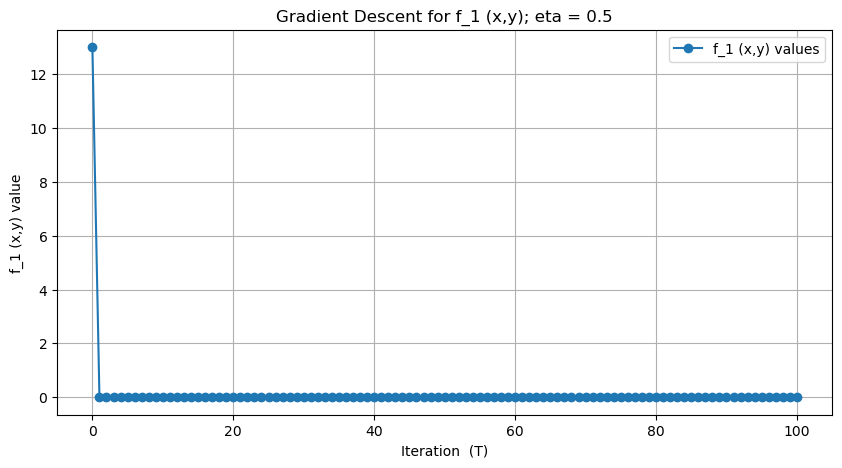

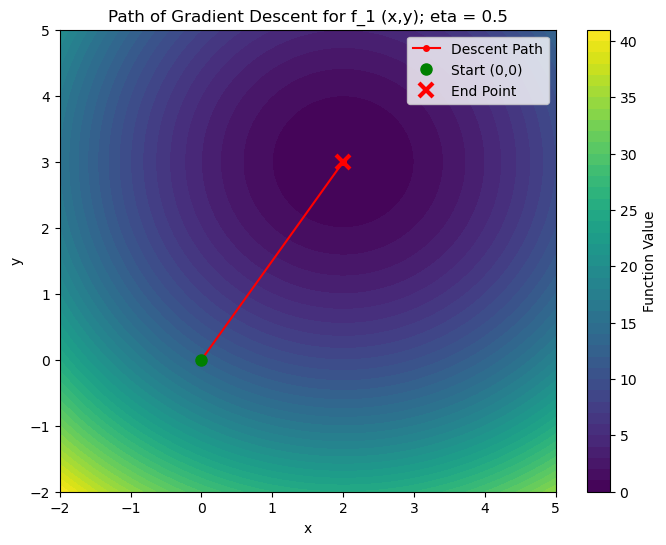

In [83]:
# Plotting for f_1 function
plt_GD(f_1_val_update, f_1_x_update, f_1_y_update, title="f_1 (x,y)", f=1)

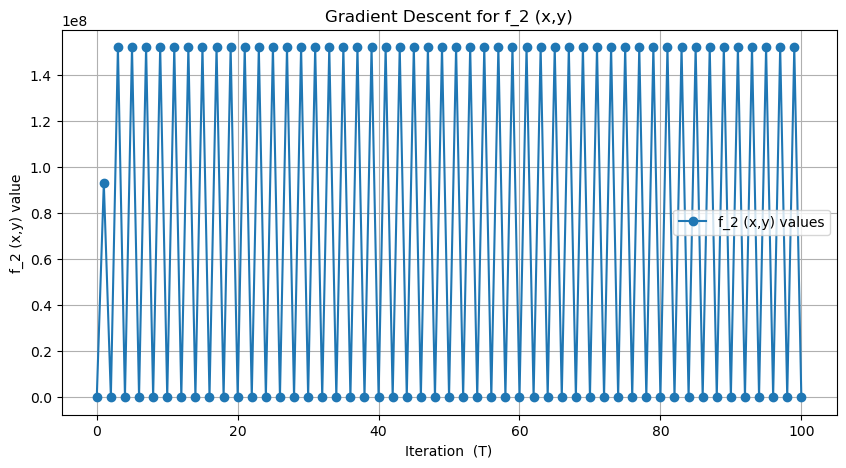

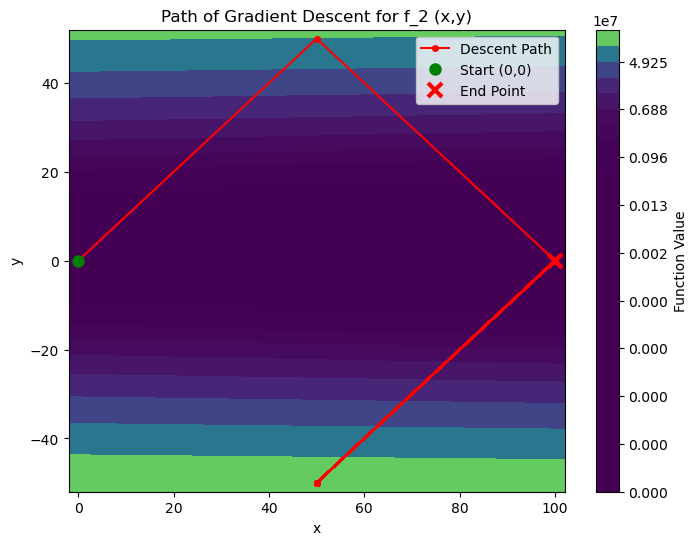

In [64]:
# Plotting for f_2 function
plt_GD(f_2_val_update, f_2_x_update, f_2_y_update, title="f_2 (x,y)", f=2)

$\eta=5$ appears to be sensitive for both functions. for f_1, while it leads directly to zero,it misses a smooth stepwise descent enterily, whereas for f_2, it is far too large, resultingin complete oversteps. As such, more subtle values of $\eta$ should be approached.

## Q9.3

More values of eta can be evaluated using the function definitions defined previously

f_1(x,y) - applying small values of eta = 0.2, 0.1, 0.09 for a more smoother gradient.

In [85]:
# f_1, eta = 0.2
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.2)

Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T       x       y      f1_value
0                0  0.0000  0.0000  1.300000e+01
1                1  0.8000  1.2000  4.680000e+00
2                2  1.2800  1.9200  1.684800e+00
3                3  1.5680  2.3520  6.065280e-01
4                4  1.7408  2.6112  2.183501e-01
..             ...     ...     ...           ...
96              96  2.0000  3.0000  2.465190e-31
97              97  2.0000  3.0000  2.465190e-31
98              98  2.0000  3.0000  2.465190e-31
99              99  2.0000  3.0000  2.465190e-31
100            100  2.0000  3.0000  2.465190e-31

[101 rows x 4 columns]


In [86]:
# f_1, eta = 0.1
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.1)

Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T       x       y      f1_value
0                0  0.0000  0.0000  1.300000e+01
1                1  0.4000  0.6000  8.320000e+00
2                2  0.7200  1.0800  5.324800e+00
3                3  0.9760  1.4640  3.407872e+00
4                4  1.1808  1.7712  2.181038e+00
..             ...     ...     ...           ...
96              96  2.0000  3.0000  3.215297e-18
97              97  2.0000  3.0000  2.057789e-18
98              98  2.0000  3.0000  1.316985e-18
99              99  2.0000  3.0000  8.428705e-19
100            100  2.0000  3.0000  5.394370e-19

[101 rows x 4 columns]


Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T         x         y      f1_value
0                0  0.000000  0.000000  1.300000e+01
1                1  0.360000  0.540000  8.741200e+00
2                2  0.655200  0.982800  5.877583e+00
3                3  0.897264  1.345896  3.952087e+00
4                4  1.095756  1.643635  2.657383e+00
..             ...       ...       ...           ...
96              96  2.000000  3.000000  3.683011e-16
97              97  2.000000  3.000000  2.476457e-16
98              98  2.000000  3.000000  1.665169e-16
99              99  2.000000  3.000000  1.119660e-16
100            100  2.000000  3.000000  7.528593e-17

[101 rows x 4 columns]


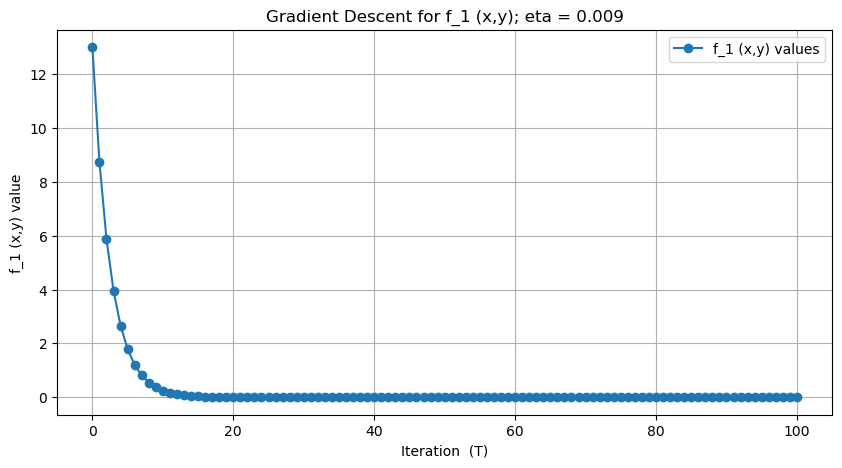

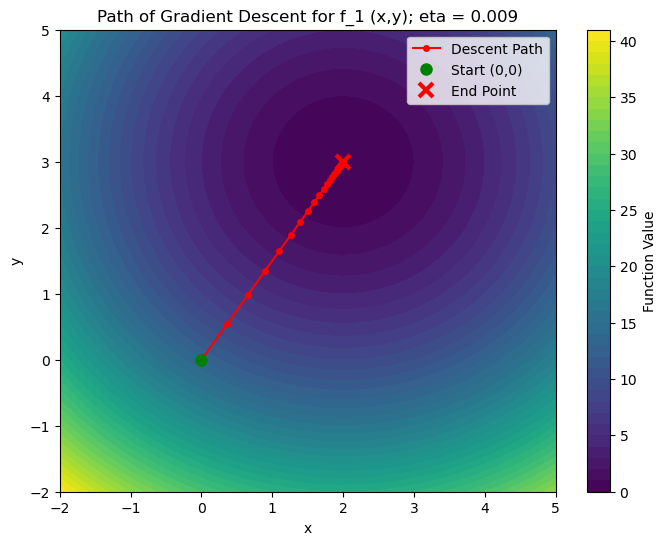

In [99]:
# f_1, eta = 0.09
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.09)
# Vizualising f_1 with eta = 0.09
plt_GD(f_1_val_update, f_1_x_update, f_1_y_update, title="f_1 (x,y)", f=1, eta=0.009)

As shown, the lower the value eta, for function 1 at least, the more 'smoother' the gradient is in terms of steps taken to get there.

Function 2 can also be evaluated with different $\eta$ values, much prefreably ones smaller than $\eta=5$. Values of eta = 0.2, 0.01, 0.001, and 0.0001 are explored for function 2.

In [ ]:
# f_2 eta = 0.2 
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.2)
# # Visualizing f_2
# plt_GD(f_2_val_update, f_2_x_update, f_2_y_update, title="f_2 (x,y)", f=2, eta=0.2)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T     x     y   f2_value
0                0   0.0   0.0      736.0
1                1  20.0  20.0  1415376.0
2                2  40.0   0.0    23136.0
3                3  20.0 -20.0  5121296.0
4                4  40.0   0.0    23136.0
..             ...   ...   ...        ...
96              96  40.0   0.0    23136.0
97              97  20.0 -20.0  5121296.0
98              98  40.0   0.0    23136.0
99              99  20.0 -20.0  5121296.0
100            100  40.0   0.0    23136.0

[101 rows x 4 columns]


In [95]:
# f_2 eta = 0.01
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.01)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T         x         y    f2_value
0                0  0.000000  0.000000  736.000000
1                1  1.000000  1.000000    9.000000
2                2  1.000000  1.060000    9.761299
3                3  0.905440  0.751907   36.930290
4                4  1.364832  1.751907  162.649777
..             ...       ...       ...         ...
96              96  0.742852  1.751907  100.548560
97              97 -0.131195  0.751907  106.044746
98              98  0.742852  1.751907  100.548560
99              99 -0.131195  0.751907  106.044746
100            100  0.742852  1.751907  100.548560

[101 rows x 4 columns]


In [96]:
# f_2 eta = 0.001
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.001)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T         x         y    f2_value
0                0  0.000000  0.000000  736.000000
1                1  0.100000  0.100000  579.132000
2                2  0.200000  0.200000  445.032000
3                3  0.300000  0.300000  332.092000
4                4  0.400000  0.400000  238.752000
..             ...       ...       ...         ...
96              96  0.709457  1.083273    8.532665
97              97  0.708033  1.083645    8.530497
98              98  0.706608  1.084018    8.528328
99              99  0.705183  1.084390    8.526160
100            100  0.703758  1.084762    8.523991

[101 rows x 4 columns]


Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T         x         y    f2_value
0                0  0.000000  0.000000  736.000000
1                1  0.010000  0.010000  719.241820
2                2  0.020000  0.020000  702.726163
3                3  0.030000  0.030000  686.451356
4                4  0.040000  0.040000  670.415731
..             ...       ...       ...         ...
96              96  0.777559  0.955214   12.528416
97              97  0.779174  0.962425   12.002546
98              98  0.780664  0.969105   11.551250
99              99  0.782039  0.975298   11.163390
100            100  0.783309  0.981044   10.829603

[101 rows x 4 columns]


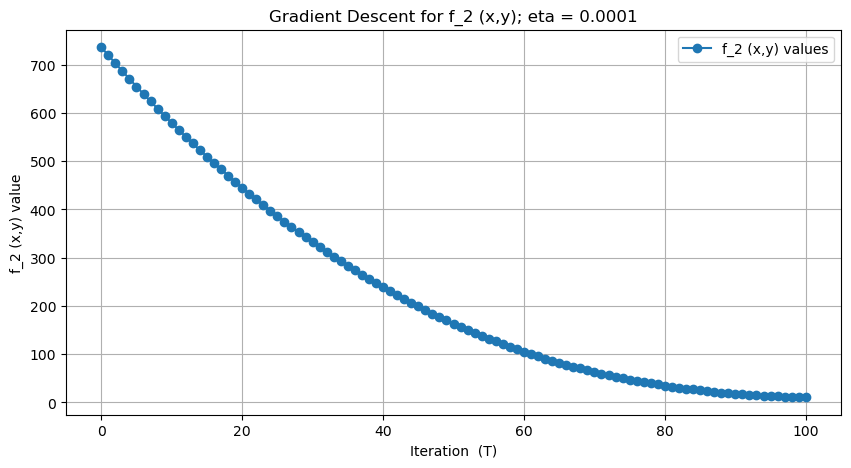

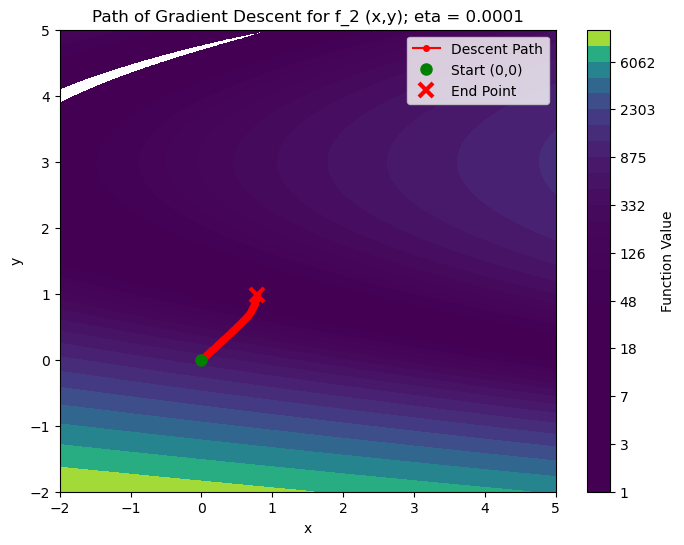

In [108]:
# f_2 eta = 0.0001
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.0001)
# Visualizing f_2
plt_GD(f_2_val_update, f_2_x_update, f_2_y_update, title="f_2 (x,y)", f=2, eta=0.0001)

Here, its is shown that unlike f_1, f_2 is much more sensitive to learning rate. At $\eta$ = 0.0001, a smooth descent can be discertained towards minimum values.

For the sake of exploration, exceptionally small vaues of $\eta$ can be explored, with $\eta=0.005$ and $\eta=0.0002$ reached to from experimenting for f_1 and f_2 respectively.

Gradient Descent for f1(x,y) with eta = 0.5
     Iteration - T         x         y   f1_value
0                0  0.000000  0.000000  13.000000
1                1  0.020000  0.030000  12.741300
2                2  0.039800  0.059700  12.487748
3                3  0.059402  0.089103  12.239242
4                4  0.078808  0.118212  11.995681
..             ...       ...       ...        ...
96              96  1.237906  1.856859   1.887560
97              97  1.245527  1.868290   1.849997
98              98  1.253071  1.879607   1.813182
99              99  1.260541  1.890811   1.777100
100            100  1.267935  1.901903   1.741736

[101 rows x 4 columns]


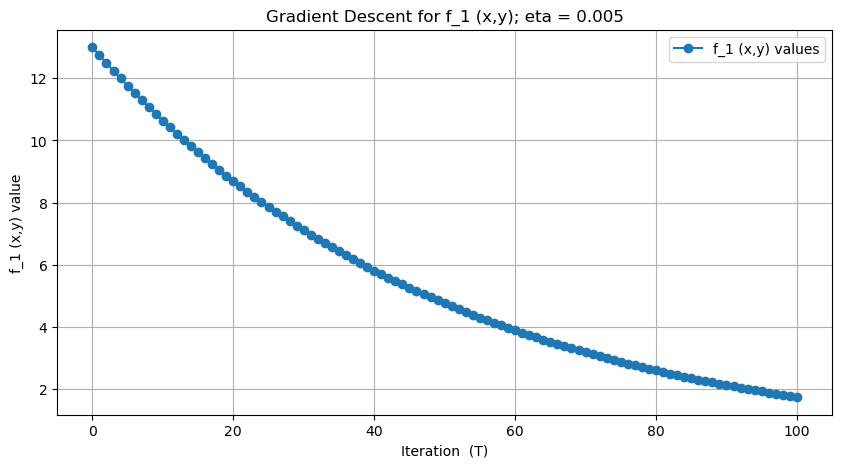

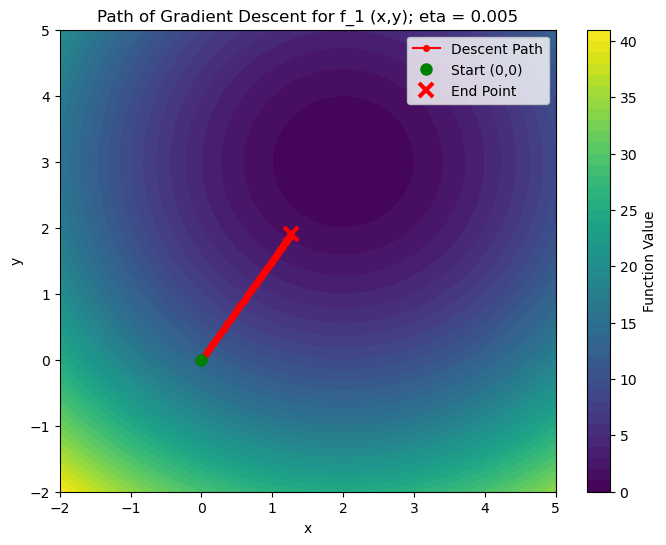

In [ ]:
# f_1 eta = 0.0005
f_1_val_update, f_1_x_update, f_1_y_update = f_1_GD(eta=0.005)
# Vizualising f_1 with eta = 0.005
plt_GD(f_1_val_update, f_1_x_update, f_1_y_update, title="f_1 (x,y)", f=1, eta=0.005)

Gradient Descent for f2(x,y) with eta = 0.001
     Iteration - T         x         y    f2_value
0                0  0.000000  0.000000  736.000000
1                1  0.020000  0.020000  702.726163
2                2  0.040000  0.040000  670.415731
3                3  0.060000  0.060000  639.055379
4                4  0.080000  0.080000  608.631859
..             ...       ...       ...         ...
96              96  0.793243  1.061381    8.659980
97              97  0.792963  1.061471    8.659548
98              98  0.792682  1.061559    8.659116
99              99  0.792401  1.061645    8.658684
100            100  0.792120  1.061729    8.658253

[101 rows x 4 columns]


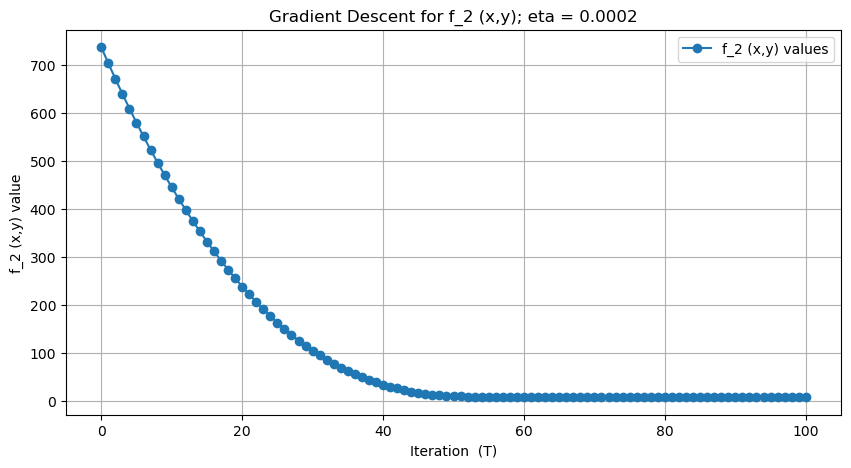

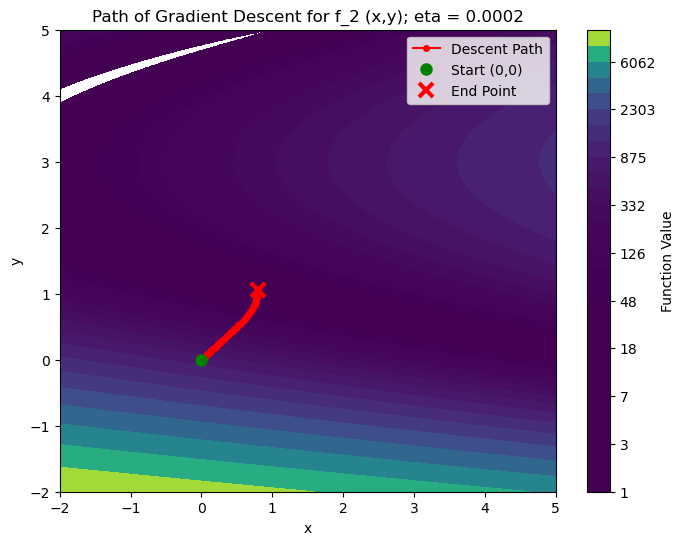

In [ ]:
# f_2 eta = 0.0002
f_2_val_update, f_2_x_update, f_2_y_update = f_2_GD(eta2=0.0002)
# Vizualising f_2 with eta = 0.0002
plt_GD(f_2_val_update, f_2_x_update, f_2_y_update, title="f_2 (x,y)", f=2, eta=0.0002)

## Q9.4

Even though the functions examined were essentially toy examples, they are important for being indicative of sepration boundaries, especially as shown in their 3d plots. Such functions, even though in higher dimensions, can seperated two classes with a decision boundary, whereupon infinite solutions can exists as to which specific values (in this case x and y) may exist. But, with Gradient decent, the best value of a decision boundary can be reached to via sequenctial steps down the gradient.

For this example, the global mininum was rudimentary and can be discertained, but there may be instances were global mininums are difficult to see intiutively, especially from advanced datasets, which the nature of the dataset can effect how decison boundaries are even formed. As displayed from the values of $\eta$ explored, a learning rate too large can result in large jumps towards the global mininum. In more complex learning applications, this can result in oscilations of learning or even erroneous results. Converesly, leraning rates too small can be inefficient, as too many steps are made to reach the global mininum. This can either result in slow learning that is inefficient (especially with time constrints) or even premature stops in learning due to the steps being too small realative to iterations. To large an $\eta$ an the learning overshoots; too small an $\eta$ and the learning undershoots. Hence, a balance in the proper $\eta$ needs to be attained, which, as construed from this toy example, can involve experimentation.